# Worksheet 4: Devnagari Digit Classification using Fully Connected Network

## Step 1: Load and Prepare Dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
import os

zip_path = "/content/drive/MyDrive/AI_Machine_Learning/Week4/devnagari_digit.zip"
extract_path = "/content/devnagari_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully!")

print(os.listdir(extract_path + "/DevanagariHandwrittenDigitDataset"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Unzipped successfully!
['Test', 'Train']


In [11]:
import os
import numpy as np
from PIL import Image
from tensorflow.keras.utils import to_categorical

train_path = "/content/devnagari_data/DevanagariHandwrittenDigitDataset/Train"
test_path  = "/content/devnagari_data/DevanagariHandwrittenDigitDataset/Test"

def load_images(path):
    images = []
    labels = []

    # go through each class folder
    for folder in os.listdir(path):
        label = int(folder.split('_')[1])   # extract digit label
        folder_path = os.path.join(path, folder)

        # read each image in the folder
        for file in os.listdir(folder_path):
            img = Image.open(os.path.join(folder_path, file)).convert("L")  # convert to grayscale
            img = img.resize((28, 28))  # resize to 28x28
            arr = np.array(img) / 255.0  # normalize pixel values (0–1)

            images.append(arr)
            labels.append(label)

    return np.array(images), np.array(labels)

# load training and testing data
X_train, y_train = load_images(train_path)
X_test, y_test = load_images(test_path)

# flatten 28x28 image into 784 vector
X_train = X_train.reshape(len(X_train), 28*28)
X_test = X_test.reshape(len(X_test), 28*28)

# convert labels into one-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# print shapes to verify
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(17000, 784) (17000, 10)
(3000, 784) (3000, 10)


## Step 2: Build the FCN Model

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# create a sequential neural network model
model = Sequential([

    Dense(64, activation='sigmoid', input_shape=(784,)),  # input layer (784) → 64 neurons
    Dense(128, activation='sigmoid'),  # hidden layer with 128 neurons
    Dense(256, activation='sigmoid'),  # hidden layer with 256 neurons
    Dense(10, activation='softmax')  # output layer (10 classes for digits 0–9)
])

# display model architecture
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

## Step 3: Compile the Model

In [13]:
# compile the model (configure training settings)
model.compile(
    optimizer='adam',  # optimizer to update weights efficiently
    loss='categorical_crossentropy',  # loss function for multi-class classification
    metrics=['accuracy']  # evaluate model using accuracy
)

## Step 4: Train the Model

In [14]:
# train the model on training data
history = model.fit(
    X_train, y_train,  # input data and labels
    epochs=20,  # number of times model sees entire dataset
    batch_size=128,  # number of samples processed at once
    validation_split=0.2  # 20% data used for validation
)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5408 - loss: 1.5543 - val_accuracy: 0.0000e+00 - val_loss: 7.0815
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8721 - loss: 0.4204 - val_accuracy: 0.0000e+00 - val_loss: 8.4289
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9268 - loss: 0.2388 - val_accuracy: 0.0000e+00 - val_loss: 9.1844
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9560 - loss: 0.1597 - val_accuracy: 0.0000e+00 - val_loss: 9.7909
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9668 - loss: 0.1190 - val_accuracy: 0.0000e+00 - val_loss: 10.3361
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9726 - loss: 0.0954 - val_accuracy: 0.0000e+00 - val_loss: 10.5559
Epoch 7/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9791 - loss: 0.0774 - val_accuracy: 0.0000e+00 - val_loss: 10.9554
Epoch 8/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9833 - 

## Step 5: Visualize Accuracy and Loss

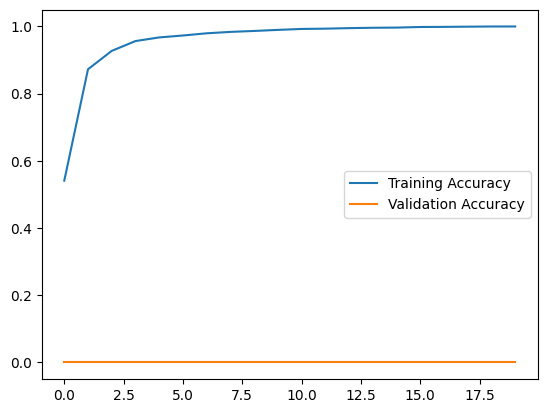

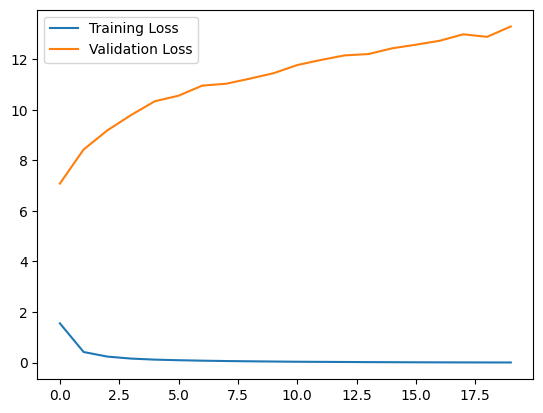

In [15]:
import matplotlib.pyplot as plt

# plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')  # training accuracy
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')  # validation accuracy
plt.legend()  # show labels
plt.show()  # display graph

# plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')  # training loss
plt.plot(history.history['val_loss'], label='Validation Loss')  # validation loss
plt.legend()  # show labels
plt.show()  # display graph

## Step 6: Evaluate the Model

In [16]:
# evaluate model on test data
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7890 - loss: 2.6725
Test Accuracy: 0.7889999747276306


## Step 7: Save and Load the Model

In [17]:
# save the trained model to a file
model.save("devnagari_fcn_model.h5")

# load the saved model
from tensorflow.keras.models import load_model
loaded = load_model("devnagari_fcn_model.h5")

# evaluate loaded model to verify saving worked
loss, acc = loaded.evaluate(X_test, y_test)
print("Loaded Model Accuracy:", acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7890 - loss: 2.6725
Loaded Model Accuracy: 0.7889999747276306


## Step 8: Predictions

In [18]:
# make predictions on first 10 test samples
pred_prob = loaded.predict(X_test[:10])  # get probability for each class

# convert probabilities to class labels
pred_labels = np.argmax(pred_prob, axis=1)
true_labels = np.argmax(y_test[:10], axis=1)

# print predicted vs actual labels
print("Predicted:", pred_labels)
print("True:", true_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Predicted: [4 4 4 4 4 4 4 4 4 4]
True: [4 4 4 4 4 4 4 4 4 4]
